In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def warn(*args, **kwargs): pass
import warnings
warnings.warn = warn

from sklearn.preprocessing import LabelEncoder
#from sklearn.cross_validation import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit


In [ ]:
data_set= pd.read_csv('drug200_v2.csv')
x= data_set.iloc[:, :-1].values
y= data_set.iloc[:, -1].values


In [ ]:
x

array([[23.   ,  2.   ,  3.   ,  1.   , 25.355],
       [47.   ,  1.   ,  1.   ,  1.   , 13.093],
       [47.   ,  1.   ,  1.   ,  1.   , 10.114],
       [28.   ,  2.   ,  2.   ,  1.   ,  7.798],
       [61.   ,  2.   ,  1.   ,  1.   , 18.043],
       [22.   ,  2.   ,  2.   ,  1.   ,  8.607],
       [49.   ,  2.   ,  2.   ,  1.   , 16.275],
       [41.   ,  1.   ,  1.   ,  1.   , 11.037],
       [60.   ,  1.   ,  2.   ,  1.   , 15.171],
       [43.   ,  1.   ,  1.   ,  2.   , 19.368],
       [47.   ,  2.   ,  1.   ,  1.   , 11.767],
       [34.   ,  2.   ,  3.   ,  2.   , 19.199],
       [43.   ,  1.   ,  1.   ,  1.   , 15.376],
       [74.   ,  2.   ,  1.   ,  1.   , 20.942],
       [50.   ,  2.   ,  2.   ,  1.   , 12.703],
       [16.   ,  2.   ,  3.   ,  2.   , 15.516],
       [69.   ,  1.   ,  1.   ,  2.   , 11.455],
       [43.   ,  1.   ,  3.   ,  1.   , 13.972],
       [23.   ,  1.   ,  1.   ,  1.   ,  7.298],
       [32.   ,  2.   ,  3.   ,  2.   , 25.974],
       [57.   ,  1. 

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.25, random_state=0)

**Data Preparation**

In [ ]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression


In [ ]:

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="rbf", C=0.025, probability=True),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GaussianNB(),
    LinearDiscriminantAnalysis(),
    LogisticRegression(random_state=0)   ]

# Logging for Visual Comparison
log_cols=["Classifier", "Accuracy", "Log Loss"]
log = pd.DataFrame(columns=log_cols)

for clf in classifiers:
    clf.fit(x_train, y_train)
    name = clf.__class__.__name__

    print("="*30)
    print(name)

    print('****Results****')
    train_predictions = clf.predict(x_test)
    acc = accuracy_score(y_test, train_predictions)
    print("Accuracy: {:.4%}".format(acc))

    train_predictions = clf.predict_proba(x_test)
    ll = log_loss(y_test, train_predictions)
    print("Log Loss: {}".format(ll))

    log_entry = pd.DataFrame([[name, acc*100, ll]], columns=log_cols)
    log = log.append(log_entry)

print("="*30)

KNeighborsClassifier
****Results****
Accuracy: 70.0000%
Log Loss: 1.802692726893788
SVC
****Results****
Accuracy: 50.0000%
Log Loss: 0.6931326066383767
DecisionTreeClassifier
****Results****
Accuracy: 100.0000%
Log Loss: 4.147793219999594e-15
RandomForestClassifier
****Results****
Accuracy: 100.0000%
Log Loss: 0.11310111851104672
GaussianNB
****Results****
Accuracy: 88.0000%
Log Loss: 0.8155895822892107
LinearDiscriminantAnalysis
****Results****
Accuracy: 90.0000%
Log Loss: 0.42355742613080677
LogisticRegression
****Results****
Accuracy: 84.0000%
Log Loss: 0.46319133791912626


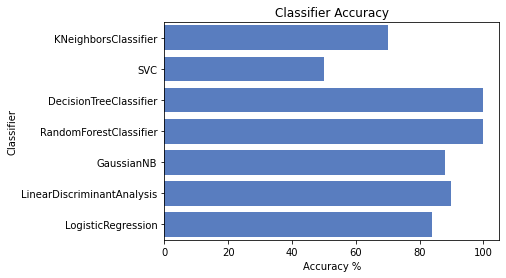

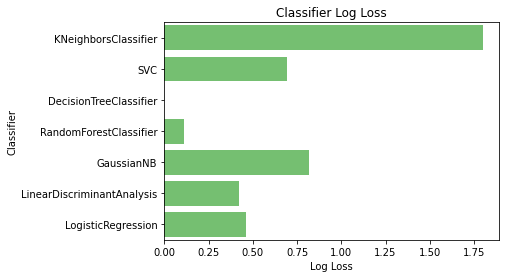

In [ ]:
sns.set_color_codes("muted")
sns.barplot(x='Accuracy', y='Classifier', data=log, color="b")

plt.xlabel('Accuracy %')
plt.title('Classifier Accuracy')
plt.show()

sns.set_color_codes("muted")
sns.barplot(x='Log Loss', y='Classifier', data=log, color="g")

plt.xlabel('Log Loss')
plt.title('Classifier Log Loss')
plt.show()

Submission

In [ ]:
# Predict Test Set
favorite_clf = DecisionTreeClassifier()
favorite_clf.fit(x_train, y_train)
test_predictions = favorite_clf.predict_proba(x_test)

# Format DataFrame
submission = pd.DataFrame(test_predictions)

submission.reset_index()

# Export Submission
#submission.to_csv('submission.csv', index = False)
submission.tail()

,0,1,2,3,4
45,0.0,0.0,0.0,1.0,0.0
46,0.0,0.0,0.0,0.0,1.0
47,0.0,0.0,0.0,0.0,1.0
48,1.0,0.0,0.0,0.0,0.0
49,0.0,0.0,0.0,0.0,1.0
